# Bank Customer Churn — Behavioral Study by **Mateus Cavalcanti**
**Objective:** Identify, validate, and communicate the strongest **behavioral drivers** of customer churn using **data analysis**.

This notebook is structured as an analytics case study:

1. Load Data
2. First Look and Dataset Validation
3. Problem Statement & Baseline: Hypothesis Formation
4. From “Profile” to “Risk”: Conditional Churn Rate by Buckets
5. Statistical Validation (Univariate): GLM (Binomial / Logit)
6. Correlation Analysis (Detect Redundancy)
7. Multivariate Model: Independent Effects
8. Minimal Behavioral Model & Score
9. Model Evaluation (AUC)
10. Considerations

> Main goal: measure **association** in a robust and interpretable way.


## Setup
This project uses **Spark** for the core analysis and modeling. I use small Python libraries Pandas only for lightweight display and visualization.

**Requirements**
- A Spark session available as `spark` (Databricks / Colab / local environment).
- Dataset: BankChurners.csv from Kaggle.


In [41]:
#Spark
!pip install pyspark
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql import functions as SF
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

#ML features
from pyspark.ml.feature import MinMaxScaler, VectorAssembler
from pyspark.ml.regression import GeneralizedLinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.linalg import VectorUDT
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.ml.stat import Correlation

# Pandas
import math
import pandas as pd

# Plot
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
# 3️⃣ Creating spark session
spark = SparkSession.builder \
    .appName("SPARK SESSION") \
    .getOrCreate()

### FUNCTIONS

In [3]:
def run_univariate_model(df, FEATURES):

  for column in FEATURES:

    print("LINEAR REGRESSION: ", column)

    assembler_uni = VectorAssembler(inputCols=[column], outputCol="features")
    df_uni = assembler_uni.transform(df).select("label", "features")

    glr_uni = GeneralizedLinearRegression(family="binomial", link="logit", regParam=0.0, maxIter=50)
    m_uni = glr_uni.fit(df_uni)
    s_uni = m_uni.summary

    beta0 = float(m_uni.intercept)
    beta1 = float(m_uni.coefficients[0])
    odds_ratio_1 = math.exp(beta1)

    results_df = pd.DataFrame({
        "term": ["Intercept", column],
        "coef": [beta0, beta1],
        "std_err": s_uni.coefficientStandardErrors,
        "t_value": s_uni.tValues,
        "p_value": s_uni.pValues
    })

    display(results_df)
    print("odds_ratio_1: ", odds_ratio_1, "\n\n")

In [4]:
def run_multivariate_model(df, FEATURES):

  assembler_full = VectorAssembler(inputCols=FEATURES, outputCol="features")
  df_full = assembler_full.transform(df).select("label", "features")

  glr_full = GeneralizedLinearRegression(family="binomial", link="logit", regParam=0.0, maxIter=50)
  m_full = glr_full.fit(df_full)
  s_full = m_full.summary

  rows = [{
      "term": "Intercept",
      "coef": float(m_full.intercept),
      "std_err": s_full.coefficientStandardErrors[0],
      "t_value": s_full.tValues[0],
      "p_value": s_full.pValues[0],
      "odds_ratio": math.exp(float(m_full.intercept))
  }]

  for i, f in enumerate(FEATURES_FULL, start=1):

    coef = float(m_full.coefficients[i-1])
    odds_ratio = math.exp(coef)

    rows.append({
          "term": f,
          "coef": float(m_full.coefficients[i-1]),
          "std_err": s_full.coefficientStandardErrors[i],
          "t_value": s_full.tValues[i],
          "p_value": s_full.pValues[i],
          "odds_ratio": odds_ratio
    })

  return pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

In [5]:
def run_correlation_analysis(df, FEATURES):

  assembler_corr = VectorAssembler(inputCols=FEATURES, outputCol="corr_features")
  df_corr = assembler_corr.transform(df.select(*FEATURES))

  corr_matrix = Correlation.corr(df_corr, "corr_features").collect()[0][0]

  corr_pd = pd.DataFrame(corr_matrix.toArray(), columns=FEATURES, index=FEATURES)
  return corr_pd


## 1. Load Data
For this repo, the dataset is stored at `/data/BankChurners.csv` in Google Colab.


In [ ]:
DATA_PATH = "/data/BankChurners.csv"

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True)

print("Rows:", df.count())
print("Columns:", len(df.columns))
df.printSchema()

Rows: 10127
Columns: 23
root
 |-- CLIENTNUM: integer (nullable = true)
 |-- Attrition_Flag: string (nullable = true)
 |-- Customer_Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Dependent_count: integer (nullable = true)
 |-- Education_Level: string (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- Income_Category: string (nullable = true)
 |-- Card_Category: string (nullable = true)
 |-- Months_on_book: integer (nullable = true)
 |-- Total_Relationship_Count: integer (nullable = true)
 |-- Months_Inactive_12_mon: integer (nullable = true)
 |-- Contacts_Count_12_mon: integer (nullable = true)
 |-- Credit_Limit: double (nullable = true)
 |-- Total_Revolving_Bal: integer (nullable = true)
 |-- Avg_Open_To_Buy: double (nullable = true)
 |-- Total_Amt_Chng_Q4_Q1: double (nullable = true)
 |-- Total_Trans_Amt: integer (nullable = true)
 |-- Total_Trans_Ct: integer (nullable = true)
 |-- Total_Ct_Chng_Q4_Q1: double (nullable = true)
 |-- Avg_Util

In [ ]:
df_show = df.toPandas()
display(df_show)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


## 2. First Look and Dataset Validation

According to the dataset description, the last two columns are not relevant for the churn analysis, so they should be dropped:

In [8]:
df = df.drop("Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1")\
       .drop("Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2")

df.columns

['CLIENTNUM',
 'Attrition_Flag',
 'Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

'CLIENTNUM' seems to be the column ID, let's confirm that:

In [9]:
df.count()

10127

In [10]:
df.select(['CLIENTNUM']).count()

10127

That's correct: each row represents a different client.

Also, the dataset does not contain an explicit date column. However, several variables summarize customer behavior over the last 12 months, which is enough for a churn behavior analysis.

For this notebook, I will treat the dataset as a recent snapshot of customer behavior.


In [11]:
df.distinct().count()

10127

The dataset also does not show duplicate rows, which is a good initial sign of data quality.

Now let's check missing values:


In [12]:
missing = df.select([
    SF.concat(SF.round(100 * (SF.count(SF.when(SF.col(c).isNull(), c)) / SF.count("*")), 2), SF.lit('%')).alias(c)
    for c in df.columns
]).toPandas()

missing

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


Although the dataset does not contain explicit `NULL` values, the preview shows the presence of `Unknown` values. Let's adapt the missing-value check to capture that as well.

In [13]:
missing = df.select([
    SF.concat(SF.round(100 * (SF.count(SF.when(SF.col(c).cast("string") == 'Unknown', 1)) / SF.count("*")), 2), SF.lit('%')).alias(c)
    for c in df.columns
]).toPandas()
missing

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0.0%,0.0%,0.0%,0.0%,0.0%,15.0%,7.4%,10.98%,0.0%,0.0%,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


Now we can see that `Education_Level`, `Marital_Status`, and `Income_Category` contain missing values, but not at a very large scale.

Among them, **Income_Category** seems the most relevant for this business context, since income level can reasonably affect product usage and churn behavior.

This detail becomes more important later, when we run analyses that require numeric discretization.


Continuing the analysis, the target column is `Attrition_Flag`. Before going deeper into the problem statement, let's inspect the full dataset profile through:
- categorical variables
- numeric variables

This is useful to understand whether the database has strong imbalance, unusual categories, or possible outliers.


In [14]:
list_of_categoric_columns = ['Gender', 'Education_Level','Marital_Status','Income_Category', 'Card_Category','Total_Relationship_Count']
df_size = df.count()

for column in list_of_categoric_columns:
  df_gouped = df.groupBy(column).agg(SF.count("*").alias("COUNT"), SF.round(100 * SF.count("*") / df_size, 2).alias("%")).orderBy(SF.col("COUNT").desc()).toPandas()
  display(df_gouped)
  print('\n')

,Gender,COUNT,%
0,F,5358,52.91
1,M,4769,47.09


,Education_Level,COUNT,%
0,Graduate,3128,30.89
1,High School,2013,19.88
2,Unknown,1519,15.00
3,Uneducated,1487,14.68
4,College,1013,10.00
5,Post-Graduate,516,5.10
6,Doctorate,451,4.45


,Marital_Status,COUNT,%
0,Married,4687,46.28
1,Single,3943,38.94
2,Unknown,749,7.40
3,Divorced,748,7.39


,Income_Category,COUNT,%
0,Less than $40K,3561,35.16
1,$40K - $60K,1790,17.68
2,$80K - $120K,1535,15.16
3,$60K - $80K,1402,13.84
4,Unknown,1112,10.98
5,$120K +,727,7.18


,Card_Category,COUNT,%
0,Blue,9436,93.18
1,Silver,555,5.48
2,Gold,116,1.15
3,Platinum,20,0.20


,Total_Relationship_Count,COUNT,%
0,3,2305,22.76
1,4,1912,18.88
2,5,1891,18.67
3,6,1866,18.43
4,2,1243,12.27
5,1,910,8.99


One thing that stands out here: `Card_Category` has almost 94% of observations in `Blue`, which appears to be the bank's most basic card category.

That is not necessarily a problem, but it is worth keeping in mind for later analysis, since such a concentrated category may have limited explanatory power.


In [15]:
list_of_numeric_columns = ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Months_Inactive_12_mon',
                          'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
                          'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
                          'Avg_Utilization_Ratio']

for column in list_of_numeric_columns:
  df_gouped = df.agg(SF.lit(column).alias("COLUMN"),
                     SF.min(column).alias("MIN"),
                     SF.percentile_approx(column, 0.10).alias("PERC_10"),
                     SF.percentile_approx(column, 0.25).alias("PERC_25"),
                     SF.percentile_approx(column, 0.50).alias("PERC_50"),
                     SF.percentile_approx(column, 0.75).alias("PERC_75"),
                     SF.percentile_approx(column, 0.90).alias("PERC_90"),
                     SF.max(column).alias("MAX")).toPandas()

  display(df_gouped)
  print("\n")

,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Customer_Age,26,36,41,46,52,57,73


,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Dependent_count,0,1,1,2,3,4,5


,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Months_on_book,13,26,31,36,40,46,56


,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Months_Inactive_12_mon,0,1,2,2,3,3,6


,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Contacts_Count_12_mon,0,1,2,2,3,4,6


...

,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Total_Amt_Chng_Q4_Q1,0.0,0.531,0.631,0.736,0.859,0.997,3.397


,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Total_Trans_Amt,510,1501,2155,3899,4741,8212,18484


,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Total_Trans_Ct,10,33,45,67,81,92,139


,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Total_Ct_Chng_Q4_Q1,0.0,0.452,0.581,0.702,0.818,0.95,3.714


,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,Avg_Utilization_Ratio,0.0,0.0,0.022,0.175,0.503,0.707,0.999


Some initial observations:

- `Months_on_book`: the minimum value is 13, which is consistent with the problem context.
- `Months_Inactive_12_mon` and `Contacts_Count_12_mon` seem to have somewhat related behavior, which also makes business sense: when a customer becomes less active, contact attempts may increase.
- `Total_Revolving_Bal`: this is an interesting variable, since it usually represents the unpaid credit card balance carried over to the next month. It may capture financial stress or payment behavior.
- `Avg_Utilization_Ratio`: it is interesting that almost 50% of the base (median ≈ 0.175) uses less than 20% of the available credit card limit.


In [16]:
print(round(100 * (df.where("Avg_Utilization_Ratio = 0").count() / df.count()), 2), "%")

24.39 %


Insight: **24.39% of the customer base has 0% credit card utilization ratio.**

Could a large share of this group belong to the churn audience?

Now that we explored the dataset from a general perspective, let's move closer to the target variable.


## 3. Problem Statement & Baseline: Hypothesis Formation
We want to understand:
- **What patterns characterize churners?** (descriptive profile)
- **Which segments have higher churn probability?** (conditional risk)
- **Which variables matter independently?** (multivariate effects)

First, let's calculate the baseline churn rate based on the normalized `Attrition_Flag`.


In [17]:
# Normalizing
df = df.withColumn("label", SF.when(SF.col("Attrition_Flag") == "Attrited Customer", 1.0).otherwise(0.0))

baseline = df.agg(SF.mean("label").alias("churn_rate")).collect()[0]["churn_rate"]
print(f"Baseline churn rate: {baseline*100:.2f}%")


Baseline churn rate: 16.07%


In churn problems, **behavioral disengagement** is often a strong signal:
- fewer transactions
- more inactivity
- lower product usage intensity

I will analyze both categorical and numerical variables, focusing on the largest differences between the two groups (`label = 0` and `label = 1`).


In [18]:
list_of_categoric_columns = ['Gender', 'Education_Level','Marital_Status','Income_Category', 'Card_Category','Total_Relationship_Count']
window_spec = Window.partitionBy("label")

for column in list_of_categoric_columns:

  df_counts = df.groupBy("label", column).agg(SF.count("*").alias("count"))

  df_final = df_counts.withColumn("percentage", SF.concat((SF.round((SF.col("count") / SF.sum("count").over(window_spec)) * 100, 2)),
                                                          SF.lit("%").cast("string")))

  df_final = df_final.select(["label", column, "Percentage"]).orderBy("label", column).toPandas()
  display(df_final)
  print("\n")

,label,Gender,Percentage
0,0.0,F,52.09%
1,0.0,M,47.91%
2,1.0,F,57.16%
3,1.0,M,42.84%


,label,Education_Level,Percentage
0,0.0,College,10.11%
1,0.0,Doctorate,4.19%
2,0.0,Graduate,31.07%
3,0.0,High School,20.08%
4,0.0,Post-Graduate,4.99%
5,0.0,Uneducated,14.71%
6,0.0,Unknown,14.86%
7,1.0,College,9.47%
8,1.0,Doctorate,5.84%
9,1.0,Graduate,29.93%


,label,Marital_Status,Percentage
0,0.0,Divorced,7.38%
1,0.0,Married,46.8%
2,0.0,Single,38.53%
3,0.0,Unknown,7.29%
4,1.0,Divorced,7.44%
5,1.0,Married,43.58%
6,1.0,Single,41.06%
7,1.0,Unknown,7.93%


,label,Income_Category,Percentage
0,0.0,$120K +,7.07%
1,0.0,$40K - $60K,17.87%
2,0.0,$60K - $80K,14.27%
3,0.0,$80K - $120K,15.21%
4,0.0,Less than $40K,34.69%
5,0.0,Unknown,10.88%
6,1.0,$120K +,7.74%
7,1.0,$40K - $60K,16.66%
8,1.0,$60K - $80K,11.62%
9,1.0,$80K - $120K,14.87%


,label,Card_Category,Percentage
0,0.0,Blue,93.14%
1,0.0,Gold,1.12%
2,0.0,Platinum,0.18%
3,0.0,Silver,5.56%
4,1.0,Blue,93.36%
5,1.0,Gold,1.29%
6,1.0,Platinum,0.31%
7,1.0,Silver,5.04%


,label,Total_Relationship_Count,Percentage
0,0.0,1,7.96%
1,0.0,2,10.55%
2,0.0,3,22.41%
3,0.0,4,19.85%
4,0.0,5,19.58%
5,0.0,6,19.65%
6,1.0,1,14.32%
7,1.0,2,21.27%
8,1.0,3,24.59%
9,1.0,4,13.83%


Among the categorical variables, the one that showed the clearest difference between labels (considering a variation above 30%, using the proportion `percentage_churn / percentage_active` for the same category value) was `Total_Relationship_Count`.

For example:
> While for label 0 the value `1` appears in 7.96% of cases, for label 1 this percentage almost doubles to 14.32%.

A similar pattern appears for values `2`, `4`, `5`, and `6`, although on a smaller scale.

For the categorical side of the EDA, this is the main variable worth keeping for the next steps.


Now, the numerics:

In [19]:
list_of_categoric_columns = ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Months_Inactive_12_mon',
                             'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
                             'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
                             'Avg_Utilization_Ratio']

for column in list_of_categoric_columns:

  df_gouped = df.groupBy("label")\
    .agg(SF.lit(column).alias("COLUMN"),
          SF.min(column).alias("MIN"),
          SF.percentile_approx(column, 0.10).alias("PERC_10"),
          SF.percentile_approx(column, 0.25).alias("PERC_25"),
          SF.percentile_approx(column, 0.50).alias("PERC_50"),
          SF.percentile_approx(column, 0.75).alias("PERC_75"),
          SF.percentile_approx(column, 0.90).alias("PERC_90"),
          SF.max(column).alias("MAX"),
          SF.round(SF.avg(column), 2).alias("AVG")).toPandas()

  display(df_gouped)
  print('\n')


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Customer_Age,26,36,41,46,52,57,73,46.26
1,1.0,Customer_Age,26,37,41,47,52,57,68,46.66


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Dependent_count,0,1,1,2,3,4,5,2.34
1,1.0,Dependent_count,0,1,2,2,3,4,5,2.40


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Months_on_book,13,25,31,36,40,46,56,35.88
1,1.0,Months_on_book,13,26,32,36,40,46,56,36.18


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Months_Inactive_12_mon,0,1,1,2,3,3,6,2.27
1,1.0,Months_Inactive_12_mon,0,2,2,3,3,4,6,2.69


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Contacts_Count_12_mon,0,1,2,2,3,4,5,2.36
1,1.0,Contacts_Count_12_mon,0,2,2,3,4,4,6,2.97


...

,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Total_Amt_Chng_Q4_Q1,0.256,0.554,0.643,0.743,0.859,1.000,3.397,0.77
1,1.0,Total_Amt_Chng_Q4_Q1,0.000,0.411,0.544,0.701,0.856,0.987,1.492,0.69


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Total_Trans_Amt,816,1531,2384,4100,4780,8356,18484,4654.66
1,1.0,Total_Trans_Amt,510,1126,1903,2329,2773,7869,10583,3095.03


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Total_Trans_Ct,11,35,54,71,82,95,139,68.67
1,1.0,Total_Trans_Ct,10,28,37,43,51,66,94,44.93


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Total_Ct_Chng_Q4_Q1,0.028,0.515,0.617,0.721,0.833,0.971,3.714,0.74
1,1.0,Total_Ct_Chng_Q4_Q1,0.000,0.300,0.400,0.531,0.692,0.839,2.500,0.55


,label,COLUMN,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX,AVG
0,0.0,Avg_Utilization_Ratio,0.0,0.0,0.055,0.211,0.529,0.711,0.994,0.30
1,1.0,Avg_Utilization_Ratio,0.0,0.0,0.000,0.000,0.231,0.641,0.999,0.16


Which numerical variables show the largest average difference between churned and active clients?
- `Avg_Utilization_Ratio` (87.5% proportion)
- `Total_Revolving_Bal` (86.7% proportion)
- `Total_Trans_Ct` (52.8% proportion)
- `Total_Trans_Amt` (50.3% proportion)


In other words, a simple group comparison shows that a client labeled as `0` has, on average, a credit card utilization of around **0.30**, while a client labeled as `1` has an average closer to **0.16**.

These four variables are therefore strong candidates for the next steps. At this point, they look like promising indicators of higher churn risk, but they still need a more formal validation.


## 4. From “Profile” to “Risk”: Conditional Churn Rate by Buckets
We do not want to look only at **P(bucket | churn)**, but also at **P(churn | bucket)**, which is the actual **risk by segment**.

To do that, I transform the variables that stood out in the EDA into simple ranges and compute the **churn rate per bucket**.

For each variable, I define practical bucket ranges based on percentile exploration.

Besides the variables highlighted in the EDA, I also include some variables that are highly relevant from a business perspective, such as inactivity time, change in transaction count, and income level.

The additional variables are:
- `Months_Inactive_12_mon`
- `Total_Ct_Chng_Q4_Q1`
- `Income_Category`


In [20]:
#Categorizing each numeric variable in buckets
df_b = (
    df.withColumn(
        "Avg_Utilization_Ratio_bucket",
        SF.when(SF.col("Avg_Utilization_Ratio") == 0, "0")
          .when(SF.col("Avg_Utilization_Ratio") <= 0.2, "0-0.2")
          .when(SF.col("Avg_Utilization_Ratio") <= 0.4, "0.2-0.4")
          .when(SF.col("Avg_Utilization_Ratio") <= 0.6, "0.4-0.6")
          .when(SF.col("Avg_Utilization_Ratio") <= 0.8, "0.6-0.8")
          .otherwise("0.8-1.0")
    )\
    .withColumn(
        "Total_Revolving_Bal_bucket",
       SF.when(SF.col("Total_Revolving_Bal") == 0, "0")
         .when(SF.col("Total_Revolving_Bal") <= 800, "0-800")
         .when(SF.col("Total_Revolving_Bal") <= 1400, "800-1400")
         .when(SF.col("Total_Revolving_Bal") <= 1800, "1400-1800")
         .when(SF.col("Total_Revolving_Bal") <= 2200, "1800-2200")
         .when(SF.col("Total_Revolving_Bal") > 2200, "2200-2500")
         .otherwise(None)
    )\
    .withColumn(
        "Total_Trans_Ct_bucket",
       SF.when(SF.col("Total_Trans_Ct") < 36, "<36")
         .when(SF.col("Total_Trans_Ct") <= 55, "37-55")
         .when(SF.col("Total_Trans_Ct") <= 70, "55-70")
         .when(SF.col("Total_Trans_Ct") <= 82, "70-82")
         .when(SF.col("Total_Trans_Ct") <= 95, "82-95")
         .when(SF.col("Total_Trans_Ct") > 95, ">95")
         .otherwise(None)
    )\
    .withColumn(
        "Total_Trans_Amt_bucket",
       SF.when(SF.col("Total_Trans_Amt") < 1500, "<1500")
         .when(SF.col("Total_Trans_Amt") <= 2300, "1500-2300")
         .when(SF.col("Total_Trans_Amt") <= 4100, "2300-4100")
         .when(SF.col("Total_Trans_Amt") <= 4700, "4100-4700")
         .when(SF.col("Total_Trans_Amt") <= 8300, "4700-8300")
         .when(SF.col("Total_Trans_Amt") > 8300, ">8300")
         .otherwise(None)
    )\
    .withColumn(
        "Months_Inactive_12_mon_bucket",
       SF.when(SF.col("Months_Inactive_12_mon") == 0, "0")
         .when(SF.col("Months_Inactive_12_mon") <= 1, "1")
         .when(SF.col("Months_Inactive_12_mon") <= 2, "2")
         .when(SF.col("Months_Inactive_12_mon") <= 3, "3")
         .when(SF.col("Months_Inactive_12_mon") > 3, ">3")
         .otherwise(None)
    )\
    .withColumn(
        "Total_Ct_Chng_Q4_Q1_bucket",
       SF.when(SF.col("Total_Ct_Chng_Q4_Q1") == 0, "0")
         .when(SF.col("Total_Ct_Chng_Q4_Q1") <= 0.2, "0-0.2")
         .when(SF.col("Total_Ct_Chng_Q4_Q1") <= 0.4, "0.2-0.4")
         .when(SF.col("Total_Ct_Chng_Q4_Q1") <= 0.6, "0.4-0.6")
         .when(SF.col("Total_Ct_Chng_Q4_Q1") <= 0.8, "0.6-0.8")
         .when(SF.col("Total_Ct_Chng_Q4_Q1") <= 1, "0.8-1")
         .when(SF.col("Total_Ct_Chng_Q4_Q1") > 1, ">1")
         .otherwise(None)
    )
)

list_of_columns = ["Avg_Utilization_Ratio_bucket", "Total_Revolving_Bal_bucket", "Total_Trans_Ct_bucket", "Total_Trans_Amt_bucket",
                   "Months_Inactive_12_mon_bucket", "Total_Ct_Chng_Q4_Q1_bucket", "Total_Relationship_Count", "Income_Category"]

for column in list_of_columns:

  buckset_counts = df_b.groupBy(column).agg(
      SF.sum("label").alias("churners"),
      SF.count("*").alias("total"),
  ).withColumn("churn_rate", SF.round(100 * SF.col("churners")/SF.col("total"), 2))

  df_results = buckset_counts.orderBy(column).toPandas()
  display(df_results)
  print("\n")

,Avg_Utilization_Ratio_bucket,churners,total,churn_rate
0,0,893.0,2470,36.15
1,0-0.2,297.0,2876,10.33
2,0.2-0.4,158.0,1565,10.10
3,0.4-0.6,98.0,1414,6.93
4,0.6-0.8,86.0,1335,6.44
5,0.8-1.0,95.0,467,20.34


,Total_Revolving_Bal_bucket,churners,total,churn_rate
0,0,893.0,2470,36.15
1,0-800,197.0,747,26.37
2,1400-1800,95.0,2025,4.69
3,1800-2200,67.0,1351,4.96
4,2200-2500,228.0,1094,20.84
5,800-1400,147.0,2440,6.02


,Total_Trans_Ct_bucket,churners,total,churn_rate
0,37-55,979.0,2275,43.03
1,55-70,201.0,2152,9.34
2,70-82,89.0,2299,3.87
3,82-95,22.0,1298,1.69
4,<36,336.0,1261,26.65
5,>95,0.0,842,0.00


,Total_Trans_Amt_bucket,churners,total,churn_rate
0,1500-2300,553.0,1819,30.40
1,2300-4100,544.0,2742,19.84
2,4100-4700,12.0,1919,0.63
3,4700-8300,176.0,1655,10.63
4,<1500,222.0,1010,21.98
5,>8300,120.0,982,12.22


,Months_Inactive_12_mon_bucket,churners,total,churn_rate
0,0,15.0,29,51.72
1,1,100.0,2233,4.48
2,2,505.0,3282,15.39
3,3,826.0,3846,21.48
4,>3,181.0,737,24.56


,Total_Ct_Chng_Q4_Q1_bucket,churners,total,churn_rate
0,0,7.0,7,100.00
1,0-0.2,52.0,65,80.00
2,0.2-0.4,356.0,620,57.42
3,0.4-0.6,616.0,2229,27.64
4,0.6-0.8,386.0,4378,8.82
5,0.8-1,168.0,2160,7.78
6,>1,42.0,668,6.29


,Total_Relationship_Count,churners,total,churn_rate
0,1,233.0,910,25.60
1,2,346.0,1243,27.84
2,3,400.0,2305,17.35
3,4,225.0,1912,11.77
4,5,227.0,1891,12.00
5,6,196.0,1866,10.50


,Income_Category,churners,total,churn_rate
0,$120K +,126.0,727,17.33
1,$40K - $60K,271.0,1790,15.14
2,$60K - $80K,189.0,1402,13.48
3,$80K - $120K,242.0,1535,15.77
4,Less than $40K,612.0,3561,17.19
5,Unknown,187.0,1112,16.82


The main output here is the **possible churn risk for each bucket analyzed**.

To estimate the real probability of a customer with behavior **X** becoming churn, I use **conditional probability**.

The logic is:
1. Identify how many churned customers fall into a given bucket (`churners`)
2. Identify how many active customers fall into the same bucket
3. Sum both groups to get the total number of customers with that behavior (`total`)
4. Compute the conditional probability:

`P(Churn | Behavior) = churners / total`

This is exactly the `churn_rate` shown in the previous output.


From the previous output, we can summarize the most relevant bucket-level insights for `churn_rate`:

- **Avg_Utilization_Ratio_bucket** has the highest `churn_rate` in bucket `0`, with a rate of **36%**.
- **Total_Revolving_Bal_bucket** also peaks in bucket `0`, with a `churn_rate` of **36%**.
- **Total_Trans_Ct_bucket** has the highest `churn_rate` in bucket `37–55`, with a rate of **43%**.
- **Total_Trans_Amt_bucket** peaks in bucket `1500–2300`, with a `churn_rate` of **30%**.
- **Months_Inactive_12_mon_bucket** has the highest `churn_rate` in bucket `0`, with **51%**, but this bucket is very small (`count = 29`). A more stable insight is that buckets with **3 or more inactive months** show a `churn_rate` of **24%**, versus only **4%** in the `0–1` bucket.
- **Total_Ct_Chng_Q4_Q1_bucket** also concentrates higher risk in the lower-value buckets. For example, the `0.2–0.4` bucket reaches **57%** churn, versus only **7%** in the `0.8–1` bucket.

To measure the strength of each indicator relative to the base rate, I also calculate **Lift**:

`Lift = Conditional Probability / Baseline Probability`

Since the overall churn rate of the base is **16%**:
- **Avg_Utilization_Ratio_bucket**: Lift = **2.25** for bucket `0`
- **Total_Revolving_Bal_bucket**: Lift = **2.25** for bucket `0`
- **Total_Trans_Ct_bucket**: Lift = **2.68** for bucket `37–55`
- **Total_Trans_Amt_bucket**: Lift = **1.87** for bucket `1500–2300`
- **Months_Inactive_12_mon_bucket**: Lift = **1.50** for buckets above `3` inactive months
- **Total_Ct_Chng_Q4_Q1_bucket**: Lift = **3.56** for bucket `0.2–0.4`


This helps quantify the size of the problem and the risk that already exists inside the customer base. We do not have only a global churn rate of 16%, we also identified subgroups with substantially higher risk.

However, to build a more solid understanding of the behavior pattern — not only descriptively, but also with predictive value — we need a statistical validation that does not depend on specific bucket thresholds.


## 5. Statistical Validation (Univariate): GLM (Binomial / Logit)

I use a **Generalized Linear Model (GLM)** with a **logit link** to run a logistic regression. This is the most appropriate approach for a binary dependent variable (Churn / Non-Churn), since it estimates the probability of the event and provides statistically validated coefficients.

This produces:
- coefficient sign (direction)
- standard error
- t-value
- p-value (evidence that the effect is not just noise)

We are measuring **association**, not causality.


Because this stage requires numeric variables, I create a numeric mapping for the categorical column `Income_Category`.

This column also contains missing values. Since the other columns do not show the same behavior, I use the **median threshold** as a simple and robust way to fill the missing cases.


In [21]:
df = df.withColumn("Income_Category_discretized", SF.when(SF.col("Income_Category") == "$120K +", 120000).otherwise(
                                                  SF.when(SF.col("Income_Category") == "$40K - $60K", 50000).otherwise(
                                                  SF.when(SF.col("Income_Category") == "$60K - $80K", 70000).otherwise(
                                                  SF.when(SF.col("Income_Category") == "$80K - $120K", 100000).otherwise(
                                                  SF.when(SF.col("Income_Category") == "Less than $40K", 40000).otherwise(50000)))))) #median

I first run the regression in a **univariate** way. The goal is to test each variable individually and reduce noise before moving to the final multivariate step.

Since the variables have very different value ranges (for example, `Total_Relationship_Count` ranges from 1 to 6, while `Income_Category` is in the tens of thousands), direct comparison of coefficients and odds ratios becomes difficult.

To make interpretation easier, I normalize all selected variables to a **0–1 range**.

This makes the final comparison of impact and importance much more intuitive.


In [22]:
list_of_columns = [
    'Total_Relationship_Count', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio',
    'Income_Category_discretized', 'Months_Inactive_12_mon'
]

stages = []
for col in list_of_columns:
    assembler = VectorAssembler(inputCols=[col], outputCol=col + "_vec", handleInvalid="skip")
    scaler = MinMaxScaler(inputCol=col + "_vec", outputCol=col + "_scaled")
    stages += [assembler, scaler]

pipeline = Pipeline(stages=stages)
model_scaled = pipeline.fit(df)
df_scaled = model_scaled.transform(df)

firstelement=udf(lambda v:float(v[0]), DoubleType())

for col in list_of_columns:
    df_scaled = df_scaled.withColumn(col + "_normalized", firstelement(col + "_scaled"))

list_final = [c + "_normalized" for c in list_of_columns]
list_final

['Total_Relationship_Count_normalized',
 'Total_Trans_Amt_normalized',
 'Total_Trans_Ct_normalized',
 'Total_Ct_Chng_Q4_Q1_normalized',
 'Total_Revolving_Bal_normalized',
 'Avg_Utilization_Ratio_normalized',
 'Income_Category_discretized_normalized',
 'Months_Inactive_12_mon_normalized']

Running the first univariate regression test with the reduced set of variables from the EDA:

In [23]:
FEATURES_FULL = [
    'Total_Relationship_Count_normalized',
    'Total_Trans_Amt_normalized',
    'Total_Trans_Ct_normalized',
    'Total_Ct_Chng_Q4_Q1_normalized',
    'Total_Revolving_Bal_normalized',
    'Avg_Utilization_Ratio_normalized',
    'Income_Category_discretized_normalized',
    'Months_Inactive_12_mon_normalized'
]

run_univariate_model(df_scaled, FEATURES_FULL)

LINEAR REGRESSION:  Total_Relationship_Count_normalized


,term,coef,std_err,t_value,p_value
0,Intercept,-0.966533,0.088844,-14.880239,0.0
1,Total_Relationship_Count_normalized,-1.322026,0.050484,-19.145480,0.0


odds_ratio_1:  0.2665945281108537 


LINEAR REGRESSION:  Total_Trans_Amt_normalized


,term,coef,std_err,t_value,p_value
0,Intercept,-0.886780,0.268463,-16.130194,0.0
1,Total_Trans_Amt_normalized,-4.330362,0.048763,-18.185676,0.0


odds_ratio_1:  0.01316277933170591 


LINEAR REGRESSION:  Total_Trans_Ct_normalized


...

odds_ratio_1:  0.11715517269522982 


LINEAR REGRESSION:  Income_Category_discretized_normalized


,term,coef,std_err,t_value,p_value
0,Intercept,-1.636641,0.083579,-0.736801,0.461243
1,Income_Category_discretized_normalized,-0.061581,0.035170,-46.535047,0.000000


odds_ratio_1:  0.9402770091464716 


LINEAR REGRESSION:  Months_Inactive_12_mon_normalized


,term,coef,std_err,t_value,p_value
0,Intercept,-2.615947,0.155262,15.034786,0.0
1,Months_Inactive_12_mon_normalized,2.334333,0.072648,-36.008338,0.0


odds_ratio_1:  10.322573756520296 




### Interpreting the coefficient
If `coef < 0`, then **higher utilization** is associated with **lower churn probability**.

A communicable measure is the **odds ratio**:
- `odds_ratio = exp(coef)`
- `odds_ratio < 1` → increasing the variable reduces churn odds
- `odds_ratio > 1` → increasing the variable increases churn odds

Some variables already show interesting behavior, although not yet in a definitive way:
- No variable showed a `p_value` above 0.05, which is a good sign. It suggests that the relationship between each variable and churn is unlikely to be random. Still, we need to confirm whether this holds in the multivariate model.
- None of the variables showed a small absolute `t_value`; all of them are on a relatively high scale. This increases confidence, since the `t_value` indicates how far the coefficient is from zero in terms of standard errors.


Looking more specifically at the coefficients and odds ratios:
- `Total_Trans_Amt` and `Total_Trans_Ct` stand out with strong coefficients and very low odds ratios, which suggests strong protective behavior against churn when transaction activity is high.
- `Total_Ct_Chng_Q4_Q1` shows the largest coefficient magnitude and also a very expressive odds ratio, making it one of the strongest initial candidates.
- The other variables show smaller, but still relevant, variations and may work as complementary signals for decision-making.

Even with these promising first insights, we still need to investigate whether some variables are overlapping in what they explain. The goal is to end up with the leanest possible list of variables that still captures the main churn behavior. For that, the next step is the correlation matrix.


## 6. Correlation Analysis (Detect Redundancy)
Correlation helps identify pairs of variables carrying similar information.

Rule of thumb:
- |corr| > 0.8: likely redundant
- 0.65–0.85: investigate
- < 0.65: usually fine


In [24]:
FEATURES_FULL = [
    'Total_Relationship_Count_normalized',
    'Total_Trans_Amt_normalized',
    'Total_Trans_Ct_normalized',
    'Total_Ct_Chng_Q4_Q1_normalized',
    'Total_Revolving_Bal_normalized',
    'Avg_Utilization_Ratio_normalized',
    'Income_Category_discretized_normalized',
    'Months_Inactive_12_mon_normalized'
]

df_results = run_correlation_analysis(df_scaled, FEATURES_FULL)
df_results

,Total_Relationship_Count_normalized,Total_Trans_Amt_normalized,Total_Trans_Ct_normalized,Total_Ct_Chng_Q4_Q1_normalized,Total_Revolving_Bal_normalized,Avg_Utilization_Ratio_normalized,Income_Category_discretized_normalized,Months_Inactive_12_mon_normalized
Total_Relationship_Count_normalized,1.000000,-0.347229,-0.241891,0.040831,0.013726,0.067663,-0.002889,-0.003675
Total_Trans_Amt_normalized,-0.347229,1.000000,0.807192,0.085581,0.064370,-0.083034,0.016924,-0.036982
Total_Trans_Ct_normalized,-0.241891,0.807192,1.000000,0.112324,0.056060,0.002838,-0.050962,-0.042787
Total_Ct_Chng_Q4_Q1_normalized,0.040831,0.085581,0.112324,1.000000,0.089861,0.074143,-0.012952,-0.038989
Total_Revolving_Bal_normalized,0.013726,0.064370,0.056060,0.089861,1.000000,0.624022,0.031593,-0.042210
Avg_Utilization_Ratio_normalized,0.067663,-0.083034,0.002838,0.074143,0.624022,1.000000,-0.300378,-0.007503
Income_Category_discretized_normalized,-0.002889,0.016924,-0.050962,-0.012952,0.031593,-0.300378,1.000000,-0.010576
Months_Inactive_12_mon_normalized,-0.003675,-0.036982,-0.042787,-0.038989,-0.042210,-0.007503,-0.010576,1.000000


From this analysis, the highest correlation in the base appears between `Total_Trans_Amt_normalized` and `Total_Trans_Ct_normalized`, which makes intuitive sense: both describe customer transaction behavior, but one measures it in count and the other in total value.

Ideally, we should keep only one of them. Since transaction **count** is usually less sensitive to extreme outliers than transaction **amount**, I choose to keep `Total_Trans_Ct_normalized`.


## 7. Multivariate Model: Independent Effects
We need to run the multivariate test because univariate effects can be inflated when variables measure overlapping behaviors.

A multivariate model answers:
> Does each variable still matter **after controlling for** the others?

Here I inspect coefficient signs, p-values, and changes in magnitude.


First, I use all the features from the univariate step, except for the variable removed in the correlation analysis. The remaining list is:

In [25]:
FEATURES_FULL = [
    'Total_Relationship_Count_normalized',
    'Total_Trans_Ct_normalized',
    'Total_Ct_Chng_Q4_Q1_normalized',
    'Total_Revolving_Bal_normalized',
    'Avg_Utilization_Ratio_normalized',
    'Income_Category_discretized_normalized',
    'Months_Inactive_12_mon_normalized'
]

results = run_multivariate_model(df_scaled, FEATURES_FULL)
results

,term,coef,std_err,t_value,p_value,odds_ratio
0,Intercept,4.379269,0.127052,-20.289928,0.000000,79.779696
1,Total_Relationship_Count_normalized,-2.577867,0.258177,-31.235055,0.000000,0.075936
2,Total_Trans_Ct_normalized,-8.064161,0.618074,-17.018384,0.000000,0.000315
3,Total_Ct_Chng_Q4_Q1_normalized,-10.518613,0.157450,-14.077884,0.000000,0.000027
4,Months_Inactive_12_mon_normalized,2.712309,0.183491,23.866349,0.000000,15.064025
5,Income_Category_discretized_normalized,-0.344124,0.206580,13.129563,0.000000,0.708841
6,Avg_Utilization_Ratio_normalized,-0.291792,0.116482,-2.954313,0.003134,0.746924
7,Total_Revolving_Bal_normalized,-2.216567,0.199205,-1.464782,0.142980,0.108983


Now I move to the feature-selection step: building a **minimal and interpretable driver set**.

The same logic from the previous topic still applies: I focus mainly on `p_value`, supported by `t_value` when useful.

Using `p_value < 0.05` as the decision rule, `Total_Revolving_Bal_normalized` changes meaningfully here: in the univariate model it looked significant, but in the multivariate model it rises to around **0.14**, which suggests that its previous effect was probably shared with other variables rather than truly independent.

So I remove this variable and run the model again.


In [26]:
FEATURES_FULL = [
    'Total_Relationship_Count_normalized',
    'Total_Trans_Ct_normalized',
    'Total_Ct_Chng_Q4_Q1_normalized',
    'Avg_Utilization_Ratio_normalized',
    'Income_Category_discretized_normalized',
    'Months_Inactive_12_mon_normalized'
]

results = run_multivariate_model(df_scaled, FEATURES_FULL)
results

,term,coef,std_err,t_value,p_value,odds_ratio
0,Intercept,4.094019,0.124282,-20.558563,0.000000e+00,59.980473
1,Total_Relationship_Count_normalized,-2.555067,0.247305,-31.879371,0.000000e+00,0.077687
2,Total_Trans_Ct_normalized,-7.883919,0.607155,-17.859824,0.000000e+00,0.000377
3,Total_Ct_Chng_Q4_Q1_normalized,-10.843683,0.143593,-16.599447,0.000000e+00,0.000020
4,Income_Category_discretized_normalized,-0.882749,0.202655,13.719461,0.000000e+00,0.413644
5,Months_Inactive_12_mon_normalized,2.780311,0.177662,23.043857,0.000000e+00,16.124039
6,Avg_Utilization_Ratio_normalized,-2.383570,0.109474,-8.063564,8.881784e-16,0.092221


Now we have the final feature selection: all remaining variables have `p_value < 0.05`.

At this point, the coefficients can be interpreted as the main behavioral drivers of churn:

1. **The churn tracker — `Months_Inactive_12_mon_normalized`**  
   This variable stands out with the highest positive odds ratio. In practical terms, customers with more inactivity are much more likely to churn.  
   **Business interpretation:** when inactivity starts rising, the customer should already be monitored as a high-risk case.

2. **The strongest protective factor — `Total_Ct_Chng_Q4_Q1_normalized`**  
   This variable captures the change in transaction count over time. Its strong negative effect suggests that maintaining or increasing transaction activity is highly associated with retention.  
   **Business interpretation:** product and marketing strategies that sustain transaction activity may directly reduce churn risk.

2. **Relationship depth — `Total_Relationship_Count_normalized`**  
   This variable represents how many different products the customer maintains with the bank. Even though its effect is not as strong as the main behavioral indicators, it still contributes meaningful signal to the model.
   Customers with a broader relationship with the institution tend to be less likely to churn. This makes intuitive sense: the more integrated the customer is with the bank's ecosystem, the higher the switching cost and the stronger the overall engagement.
   
   **Business interpretation**: encouraging customers to adopt additional products (for example savings accounts, loans, or other financial services) may indirectly improve retention by strengthening the overall relationship.

4. **Credit card usage intensity — `Avg_Utilization_Ratio_normalized`**  
   This variable also acts as a protective factor. It adds a complementary perspective: not just whether the client transacts, but how actively the available credit is being used.

5. **Support variables**  
   The remaining variables still add signal, but in a more complementary role than the three above.


## 8. Minimal Behavioral Model & Score
A compact and actionable set is:

- `Total_Trans_Ct` (transaction frequency / engagement)
- `Total_Ct_Chng_Q4_Q1` (evolution of transaction frequency / engagement)
- `Months_Inactive_12_mon` (inactivity)
- `Avg_Utilization_Ratio` (usage intensity)
- `Income_Category` (financial profile)
- `Total_Relationship_Count` (relationship depth with the bank)


With these validated variables, I can build a simple **risk score** that estimates, in percentage terms, how likely a customer is to become churn based on the patterns found in the analysis.


In [27]:
FEATURES_FINAL = [
    'Total_Relationship_Count_normalized',
    'Total_Trans_Ct_normalized',
    'Total_Ct_Chng_Q4_Q1_normalized',
    'Avg_Utilization_Ratio_normalized',
    'Income_Category_discretized_normalized',
    'Months_Inactive_12_mon_normalized'
]

assembler_final = VectorAssembler(inputCols=FEATURES_FINAL, outputCol="features_final")
df_final = assembler_final.transform(df_scaled)

lr = LogisticRegression(featuresCol="features_final", labelCol="label", regParam=0.0)
model_lr = lr.fit(df_final)

predictions = model_lr.transform(df_final)

df_scored = predictions.withColumn("prob_array", vector_to_array("probability")) \
                       .withColumn("churn_score_pct", SF.round(SF.col("prob_array")[1] * 100, 2))

df_scored

DataFrame[CLIENTNUM: int, Attrition_Flag: string, Customer_Age: int, Gender: string, Dependent_count: int, Education_Level: string, Marital_Status: string, Income_Category: string, Card_Category: string, Months_on_book: int, Total_Relationship_Count: int, Months_Inactive_12_mon: int, Contacts_Count_12_mon: int, Credit_Limit: double, Total_Revolving_Bal: int, Avg_Open_To_Buy: double, Total_Amt_Chng_Q4_Q1: double, Total_Trans_Amt: int, Total_Trans_Ct: int, Total_Ct_Chng_Q4_Q1: double, Avg_Utilization_Ratio: double, label: double, Income_Category_discretized: int, Total_Relationship_Count_vec: vector, Total_Relationship_Count_scaled: vector, Total_Trans_Amt_vec: vector, Total_Trans_Amt_scaled: vector, Total_Trans_Ct_vec: vector, Total_Trans_Ct_scaled: vector, Total_Ct_Chng_Q4_Q1_vec: vector, Total_Ct_Chng_Q4_Q1_scaled: vector, Total_Revolving_Bal_vec: vector, Total_Revolving_Bal_scaled: vector, Avg_Utilization_Ratio_vec: vector, Avg_Utilization_Ratio_scaled: vector, Income_Category_discre

In [28]:
df_results = df_scored.select(["CLIENTNUM", "label", "Total_Relationship_Count", "Total_Trans_Ct",
                          "Total_Ct_Chng_Q4_Q1", "Avg_Utilization_Ratio", "Income_Category", "Months_Inactive_12_mon", "churn_score_pct"]).toPandas()
display(df_results)

,CLIENTNUM,label,Total_Relationship_Count,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Income_Category,Months_Inactive_12_mon,churn_score_pct
0,768805383,0.0,5,42,1.625,0.061,$60K - $80K,1,0.93
1,818770008,0.0,6,33,3.714,0.105,Less than $40K,1,0.00
2,713982108,0.0,4,20,2.333,0.000,$80K - $120K,1,0.63
3,769911858,0.0,3,20,2.333,0.760,Less than $40K,4,1.32
4,709106358,0.0,5,28,2.500,0.000,$60K - $80K,1,0.20
...,...,...,...,...,...,...,...,...,...
10122,772366833,0.0,3,117,0.857,0.462,$40K - $60K,2,0.19
10123,710638233,1.0,4,69,0.683,0.511,$40K - $60K,2,3.10
10124,716506083,1.0,5,60,0.818,0.000,Less than $40K,3,11.88
10125,717406983,1.0,4,62,0.722,0.000,$40K - $60K,3,19.07


Let's compare the average risk score of customers who stayed (`label = 0`) versus customers who churned (`label = 1`).

In [29]:
# Average churn score
df_results = df_scored.groupBy("label").agg(
    SF.round(SF.avg("churn_score_pct"), 2).alias("avg_churn_score_pct"),
    SF.count("*").alias("total")
).toPandas()

display(df_results)

,label,avg_churn_score_pct,total
0,0.0,10.09,8500
1,1.0,47.27,1627


The average score is much higher for customers who churned — around **47%** — compared to approximately **10%** for customers who stayed.

This is a good practical sign that the score is capturing the behavioral separation we were looking for.


In [32]:
# Average churn score
df_results = df_scored.groupBy("label").agg(
    SF.min("churn_score_pct").alias("MIN"),
    SF.percentile_approx("churn_score_pct", 0.10).alias("PERC_10"),
    SF.percentile_approx("churn_score_pct", 0.25).alias("PERC_25"),
    SF.percentile_approx("churn_score_pct", 0.50).alias("PERC_50"),
    SF.percentile_approx("churn_score_pct", 0.75).alias("PERC_75"),
    SF.percentile_approx("churn_score_pct", 0.90).alias("PERC_90"),
    SF.max("churn_score_pct").alias("MAX")
).toPandas()

display(df_results)

,label,MIN,PERC_10,PERC_25,PERC_50,PERC_75,PERC_90,MAX
0,0.0,0.00,0.63,1.58,4.28,11.7,28.10,93.87
1,1.0,0.28,7.57,20.58,46.58,73.0,87.69,99.13


## 9. Model Evaluation (AUC)
AUC evaluates **the model as a whole** (all selected features together), not a single variable.

We use Spark's `LogisticRegression` classifier here because it outputs `rawPrediction`, which is suitable for ROC/AUC evaluation.


In [ ]:
FEATURES = [
    'Total_Relationship_Count_normalized',
    'Total_Trans_Ct_normalized',
    'Total_Ct_Chng_Q4_Q1_normalized',
    'Avg_Utilization_Ratio_normalized',
    'Income_Category_discretized_normalized',
    'Months_Inactive_12_mon_normalized'
]

assembler_min = VectorAssembler(inputCols=FEATURES, outputCol="features")
df_min = assembler_min.transform(df_scaled).select("label", "features")

train_min, test_min = df_min.randomSplit([0.7, 0.3], seed=42)

lr_eval = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100, regParam=0.0)
lr_model = lr_eval.fit(train_min)

pred = lr_model.transform(test_min)

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(pred)
print("AUC (minimal behavioral model):", auc)


AUC (minimal behavioral model): 0.867863973393053


> Customers with predicted churn probability above 0.7 could be flagged for retention campaigns.

Plotting ROC curve:

AUC from sklearn: 86.79 %


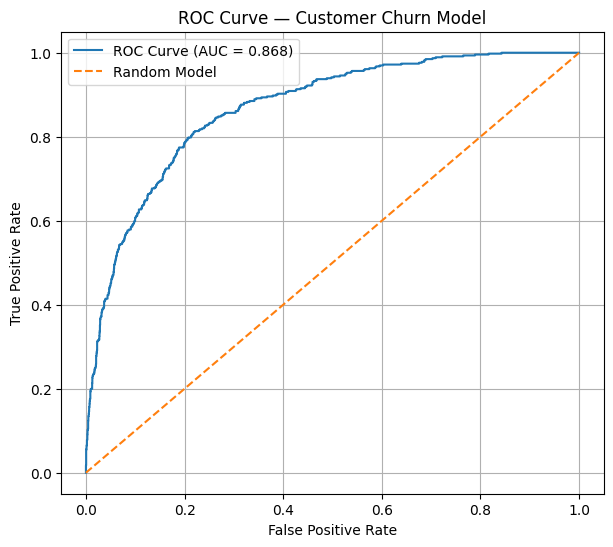

In [42]:
pred_pd = (
    pred
    .select(
        "label",
        vector_to_array("probability")[1].alias("churn_probability")
    )
    .toPandas()
)

# ROC curve
fpr, tpr, thresholds = roc_curve(
    pred_pd["label"],
    pred_pd["churn_probability"]
)

roc_auc = auc(fpr, tpr)

print("AUC from sklearn:", round(100 * roc_auc, 2), "%")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Customer Churn Model")
plt.legend()
plt.grid(True)

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


The ROC curve shows that the model has a strong ability to distinguish churners from active customers.

With an AUC of 0.868, the model correctly ranks churners above non-churners in approximately 86.8% of cases, indicating that the selected behavioral variables contain meaningful predictive signal.

This result suggests that transaction behavior, utilization patterns, and relationship depth are strong indicators of customer engagement and potential churn risk.

## 10. Considerations
**Core story:** churn in this dataset is primarily linked to **declining engagement**, not to a single isolated demographic factor.

**Evidence built throughout the notebook:**
- The EDA already suggested that churned customers differ from active customers mainly in behavioral variables such as transaction activity, inactivity, and card usage intensity.
- The bucket analysis converted those differences into **conditional risk**, showing that some customer segments are far riskier than the portfolio average.
- The univariate GLM confirmed that the main candidate variables are statistically associated with churn.
- The correlation step helped remove redundant information, especially between transaction amount and transaction count.
- The multivariate GLM showed which effects remain relevant **independently**, after controlling for overlap between variables.
- The final score and AUC indicate that the selected variables are not only interpretable, but also useful for separating higher-risk from lower-risk customers.

**Business implications:**
- Customers with rising inactivity should be monitored early, before churn becomes visible in the aggregate churn rate.
- Maintaining transaction activity appears to be one of the strongest protective factors, so this should be a central lever for retention campaigns.
- Credit card utilization also matters, but more as a complementary behavioral signal than as a standalone explanation.
- A compact model with a few interpretable variables is enough to support a practical churn-monitoring framework.

**Next steps:**
- Validate the score over time with an out-of-time sample, if a dated dataset becomes available
- Test threshold-based retention actions (for example, top-risk deciles)
- Compare this interpretable baseline with more advanced models, such as tree-based methods, while preserving explainability
- Include additional behavioral signals, if available, such as digital engagement, customer service interactions, or complaints history

**Final note:** This notebook is part of an ongoing learning process. Mistakes may occur, and I am always open to learning and correcting them.
